In [ ]:
# =========================================================
#  ANALYSIS SCRIPT  — Influenza Mortality (New England)
# Story: Can early-season surveillance predict end-of-season mortality?
# =========================================================

# =========================================================
# 0. Setup
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(style="whitegrid")

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# remove grid when needed:
# plt.grid(False)  # or: ax.grid(False)


In [2]:
# =========================================================
# 1. Load data
# =========================================================
mort = pd.read_csv("NewEngland_Influenza_Mortality_2020-2025.csv")
age_season = pd.read_csv("AgeViewBySeason.csv")
ili_age_week = pd.read_csv("ILIAgeSummaryDataByWeek.csv")
virus = pd.read_csv("VirusViewBySeason.csv")
ilin = pd.read_csv("ILINet.csv", skiprows=1)


In [3]:
# =========================================================
# 2. Clean + transform
# =========================================================

# ---- Mortality ----
mort["num_influenza_deaths"] = pd.to_numeric(mort["num_influenza_deaths"], errors="coerce")
mort["total_deaths"] = pd.to_numeric(mort["total_deaths"], errors="coerce")
mort["season"] = mort["season"].astype(str)
mort["week"] = mort["week"].astype(int)

new_england_states = ["Connecticut", "Maine", "Massachusetts", "New Hampshire", "Rhode Island", "Vermont"]
mort_ne = mort[mort["state"].isin(new_england_states)].copy()

# ---- AgeViewBySeason ----
age_season.columns = age_season.columns.str.strip()
age_season["Season"] = age_season["Season"].astype(str)
age_season["Age Group"] = age_season["Age Group"].astype(str)
virus_cols = [c for c in age_season.columns if c not in ["Season", "Age Group"]]
age_season["Total_Viruses"] = age_season[virus_cols].sum(axis=1)

# ---- ILIAgeSummaryDataByWeek ----
ili_age_week.columns = ili_age_week.columns.str.strip()
ili_age_week = ili_age_week.rename(columns={"ILI_Percent ": "ILI_Percent"})
ili_age_week["Year"] = ili_age_week["Year"].astype(int)
ili_age_week["Week"] = ili_age_week["Week"].astype(int)
ili_age_week["ILI_Percent"] = pd.to_numeric(ili_age_week["ILI_Percent"], errors="coerce")

# ---- VirusViewBySeason ----
virus.columns = virus.columns.str.strip()
virus["Season"] = virus["Season"].astype(str)
virus["Virus_Total"] = virus[["0-4 yr","5-24 yr","25-64 yr","65+ yr"]].sum(axis=1)

# ---- ILINet ----
ilin.columns = ilin.columns.str.strip()
ilin["YEAR"] = ilin["YEAR"].astype(int)
ilin["WEEK"] = ilin["WEEK"].astype(int)

for col in ["% WEIGHTED ILI", "%UNWEIGHTED ILI"]:
    ilin[col] = pd.to_numeric(ilin[col], errors="coerce")

def derive_season_ilinet(row):
    y, w = row["YEAR"], row["WEEK"]
    if w >= 40:
        return f"{y}-{str((y + 1) % 100).zfill(2)}"
    else:
        return f"{y-1}-{str(y % 100).zfill(2)}"

ilin["season"] = ilin.apply(derive_season_ilinet, axis=1)

ilin_ne = ilin[ilin["REGION"].isin(new_england_states)].copy()
ilin_ne = ilin_ne.rename(columns={"REGION":"state"})

In [4]:

# =========================================================
# 2b. Fix pissue: skip Massachusetts in mortality-rate tables
# (because total_deaths has zeros → rate invalid)
# =========================================================
states_keep = ["Connecticut", "Maine", "New Hampshire", "Rhode Island", "Vermont"]
mort_ne_clean = mort_ne[mort_ne["state"].isin(states_keep)].copy()
ilin_ne_clean = ilin_ne[ilin_ne["state"].isin(states_keep)].copy()


In [5]:
# =========================================================
# 3. SUMMARY STAT TABLES (several)
# =========================================================

# ---- Table 1 (wide): season deaths by state ----
summary_state_season = (
    mort_ne_clean.groupby(["state","season"], as_index=False)
    .agg(
        influenza_deaths=("num_influenza_deaths","sum"),
        total_deaths=("total_deaths","sum"),
    )
)

# death rate only when denominator > 0
summary_state_season["influenza_death_rate_pct"] = np.where(
    summary_state_season["total_deaths"] > 0,
    100 * summary_state_season["influenza_deaths"] / summary_state_season["total_deaths"],
    np.nan
)

table1_wide_deaths = summary_state_season.pivot_table(
    index="state", columns="season", values="influenza_deaths", aggfunc="sum"
).sort_index()

table2_wide_rate = summary_state_season.pivot_table(
    index="state", columns="season", values="influenza_death_rate_pct", aggfunc="mean"
).sort_index()

# ---- Table 3: ILINet state-season summary ----
ilin_season_state = (
    ilin_ne_clean.groupby(["state","season"], as_index=False)
    .agg(
        mean_unweighted_ili=("%UNWEIGHTED ILI", "mean"),
        total_patients=("TOTAL PATIENTS","sum"),
        ilitotal=("ILITOTAL","sum"),
    )
)

ilin_season_state["ili_pct_from_counts"] = 100 * (
    ilin_season_state["ilitotal"] / ilin_season_state["total_patients"].replace(0, np.nan)
)

table3_wide_ili = ilin_season_state.pivot_table(
    index="state", columns="season", values="mean_unweighted_ili", aggfunc="mean"
).sort_index()

# ---- Table 4: lab-confirmed totals by season & age ----
summary_age_season = (
    age_season.groupby(["Season","Age Group"], as_index=False)
    .agg(total_lab_confirmed=("Total_Viruses","sum"))
)

# ---- Table 5: mean ILI% by age group ----
summary_ili_age = (
    ili_age_week.dropna(subset=["ILI_Percent"])
    .groupby("Age", as_index=False)
    .agg(mean_ili_percent=("ILI_Percent","mean"))
)

print("\nTABLE 1 (Wide): Influenza deaths by state-season")
print(table1_wide_deaths.fillna(0).astype(int))

print("\nTABLE 2 (Wide): Influenza death rate (%) by state-season")
print(table2_wide_rate.round(2))

print("\nTABLE 3 (Wide): Mean unweighted ILI by state-season")
print(table3_wide_ili.round(2))

print("\nTABLE 4: Lab-confirmed totals by season & age (head)")
print(summary_age_season.head(12))

print("\nTABLE 5: Mean ILI% by age group")
print(summary_ili_age.round(2))



TABLE 1 (Wide): Influenza deaths by state-season
season         2020-21  2021-22  2022-23  2023-24  2024-25
state                                                     
Connecticut          0       29       92      122      215
Maine                4       15       84       56      110
New Hampshire        2       21       45       56       90
Rhode Island         2        9       31       53       63
Vermont              1        5       37       35       63

TABLE 2 (Wide): Influenza death rate (%) by state-season
season         2020-21  2021-22  2022-23  2023-24  2024-25
state                                                     
Connecticut       0.00     0.08     0.28     0.37     0.69
Maine             0.02     0.08     0.50     0.34     0.68
New Hampshire     0.01     0.14     0.32     0.40     0.66
Rhode Island      0.02     0.08     0.30     0.51     0.64
Vermont           0.02     0.07     0.54     0.54     1.00

TABLE 3 (Wide): Mean unweighted ILI by state-season
season       

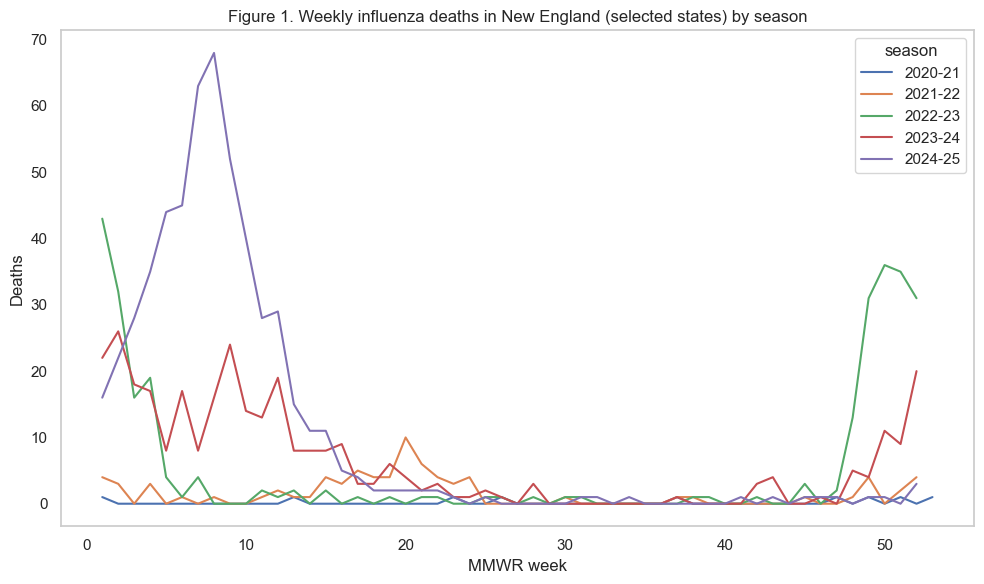

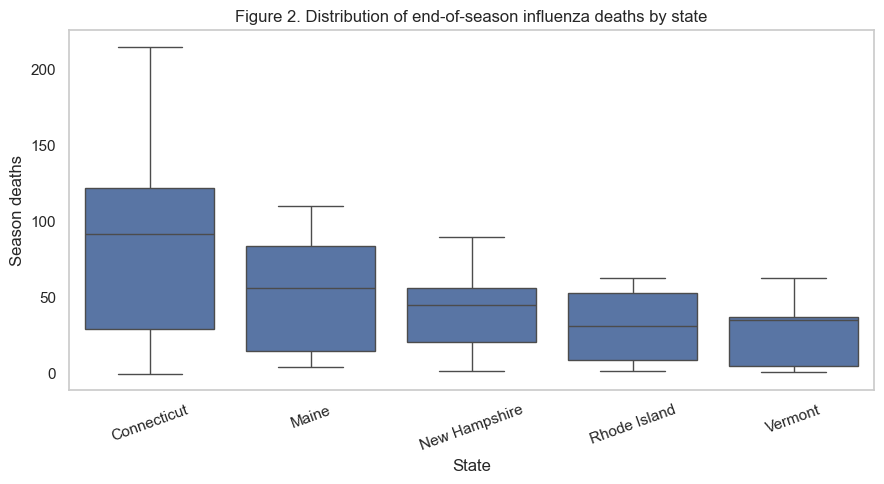

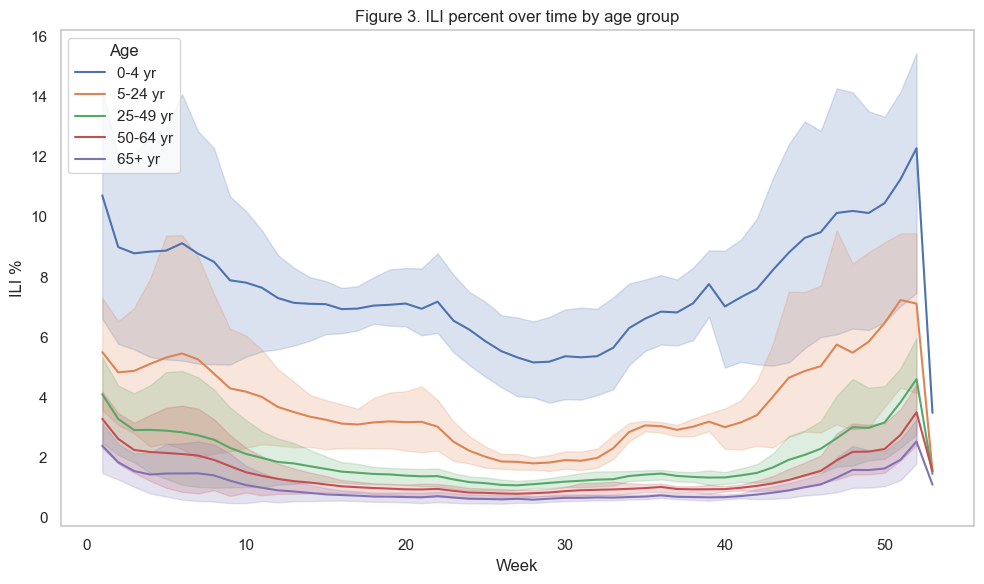

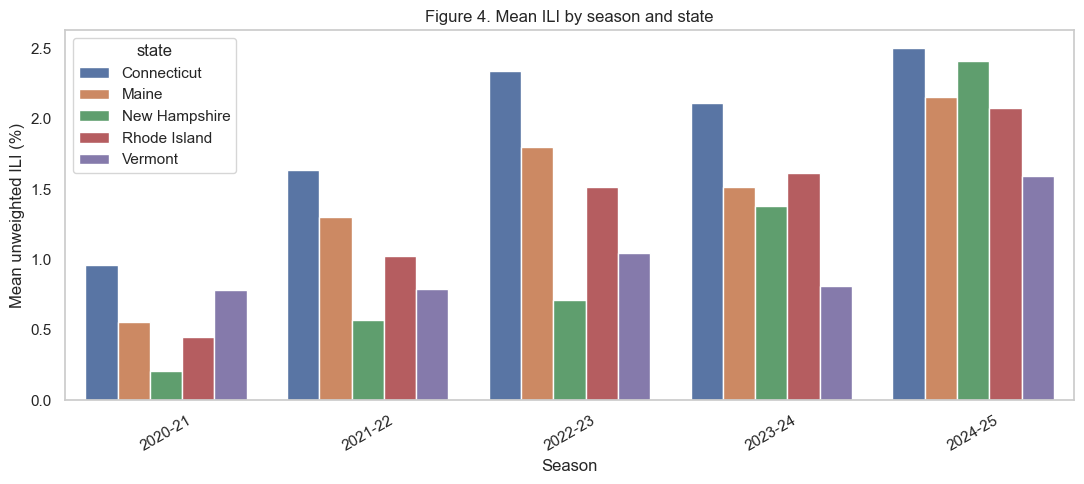

In [48]:
# =========================================================
# 4. CHARTS (distributions by group)
# =========================================================
 
# Fig 1: Year-over-year epi curve (weekly deaths by season)
mort_weekly = (
    mort_ne_clean.groupby(["season","week"], as_index=False)
    .agg(total_influenza_deaths=("num_influenza_deaths","sum"))
)

plt.figure(figsize=(10,6))
sns.lineplot(data=mort_weekly, x="week", y="total_influenza_deaths", hue="season")
plt.title("Figure 1. Weekly influenza deaths in New England (selected states) by season")
plt.xlabel("MMWR week")
plt.ylabel("Deaths")
plt.grid(False)
plt.tight_layout()
plt.show()

# Fig 2: Distribution of season deaths by state (boxplot)
season_totals = (
    mort_ne_clean.groupby(["state","season"], as_index=False)
    .agg(season_deaths=("num_influenza_deaths","sum"))
)

plt.figure(figsize=(9,5))
sns.boxplot(data=season_totals, x="state", y="season_deaths")
plt.title("Figure 2. Distribution of end-of-season influenza deaths by state")
plt.xlabel("State")
plt.ylabel("Season deaths")
plt.xticks(rotation=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# Fig 3: Age ILI distribution over time
plt.figure(figsize=(10,6))
sns.lineplot(data=ili_age_week, x="Week", y="ILI_Percent", hue="Age")
plt.title("Figure 3. ILI percent over time by age group")
plt.xlabel("Week")
plt.ylabel("ILI %")
plt.grid(False)
plt.tight_layout()
plt.show()

# Fig 4: Grouped bar chart (mean ILI by state-season)
plt.figure(figsize=(11,5))
sns.barplot(data=ilin_season_state, x="season", y="mean_unweighted_ili", hue="state")
plt.title("Figure 4. Mean ILI by season and state")
plt.xlabel("Season")
plt.ylabel("Mean unweighted ILI (%)")
plt.xticks(rotation=30)
plt.grid(False)
plt.tight_layout()
plt.show()

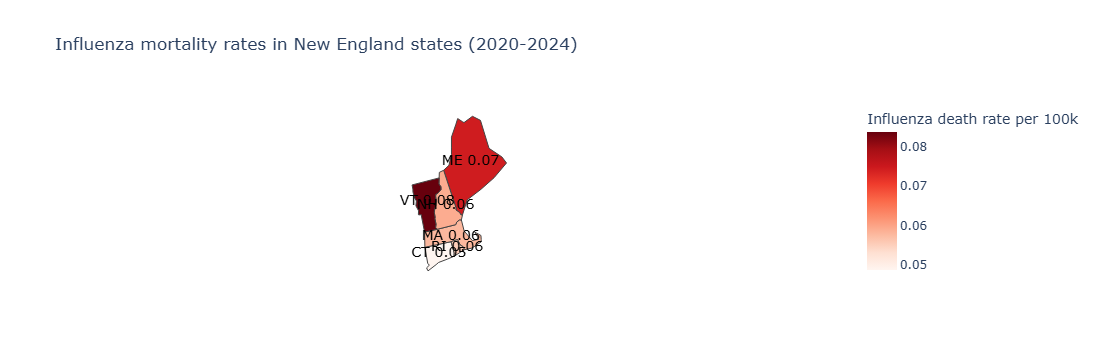

In [36]:
# ----------------------------------------------
# Map: Influenza mortality rates in New England (2020-2024)
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
# Load dataset
df = pd.read_csv('NewEngland_Influenza_Mortality_2020-2025.csv')
df['year'] = df['season'].str[:4].astype(int)

# State population (thousands) from FRED
pop_data = {
    'Connecticut': {2020: 3579.918, 2021: 3606.607, 2022: 3617.925, 2023: 3643.023, 2024: 3675.069},
    'Maine': {2020: 1364.571, 2021: 1378.931, 2022: 1390.922, 2023: 1399.646, 2024: 1405.012},
    'Massachusetts': {2020: 6994.598, 2021: 7000.474, 2022: 7022.468, 2023: 7066.568, 2024: 7136.171},
    'New Hampshire': {2020: 1378.756, 2021: 1387.677, 2022: 1396.678, 2023: 1402.199, 2024: 1409.032},
    'Rhode Island': {2020: 1096.530, 2021: 1097.246, 2022: 1099.498, 2023: 1103.429, 2024: 1112.308},
    'Vermont': {2020: 642.977, 2021: 647.210, 2022: 648.142, 2023: 648.708, 2024: 648.493}
}

# Compute population for each record
df['population'] = [pop_data[row.state][row.year] * 1000 for row in df.itertuples()]
df['num_influenza_deaths'] = pd.to_numeric(df['num_influenza_deaths'], errors='coerce')
df['death_rate_per_100k'] = df['num_influenza_deaths'] / df['population'] * 100000

# Aggregate by state across 2020-2024
agg = df[df['year'].between(2020, 2024)].groupby('state').agg({
    'num_influenza_deaths': 'sum',
    'population': 'sum'
}).reset_index()
agg['rate_per_100k'] = agg['num_influenza_deaths'] / agg['population'] * 100000

# Map states to postal codes
state_abbrev = {'Connecticut': 'CT', 'Maine': 'ME', 'Massachusetts': 'MA', 'New Hampshire': 'NH', 'Rhode Island': 'RI', 'Vermont': 'VT'}
agg['state_code'] = agg['state'].map(state_abbrev)

# Create labels with rate numbers (rounded to 2 decimals)
agg['label'] = agg['state_code'] + ' ' + agg['rate_per_100k'].round(2).astype(str)

# Create choropleth map
fig = px.choropleth(
    agg,
    locations='state_code',
    locationmode='USA-states',
    color='rate_per_100k',
    color_continuous_scale='Reds',
    scope='usa',
    labels={'rate_per_100k': 'Influenza death rate per 100k'},
    title='Influenza mortality rates in New England states (2020-2024)'
)
# Overlay text labels
fig.add_trace(go.Scattergeo(
    locations=agg['state_code'],
    locationmode='USA-states',
    text=agg['label'],
    mode='text',
    showlegend=False,
    textfont=dict(size=14, color='black')
))

fig.update_geos(fitbounds='locations', visible=False)
fig.show()


In [7]:
# =========================================================
# 5. MERGE for modeling
# =========================================================

# virus totals by season
virus_season_total = virus.groupby("Season", as_index=False).agg(total_virus_count=("Virus_Total","sum"))

# combine mortality + ili + virus at state-season level
model_df = season_totals.merge(
    ilin_season_state[["state","season","mean_unweighted_ili","ili_pct_from_counts","total_patients"]],
    on=["state","season"],
    how="left"
).merge(
    virus_season_total,
    left_on="season",
    right_on="Season",
    how="left"
)

model_df["total_virus_count"] = model_df["total_virus_count"].fillna(0)

In [8]:
# =========================================================
# 6. INFERENTIAL ANALYSIS (significant predictors)
# Option A: OLS (simple)
# Option B: Poisson GLM (count outcome)
# =========================================================

infer_df = model_df.dropna(subset=["season_deaths","mean_unweighted_ili"]).copy()

# --- OLS ---
ols = smf.ols("season_deaths ~ mean_unweighted_ili + total_patients + total_virus_count + C(state) + C(season)", data=infer_df).fit()
print("\n=== OLS Regression Summary ===")
print(ols.summary())

# --- Poisson GLM (more appropriate for counts) ---
poisson = smf.glm(
    "season_deaths ~ mean_unweighted_ili + total_patients + total_virus_count + C(state) + C(season)",
    data=infer_df,
    family=sm.families.Poisson()
).fit()
print("\n=== Poisson GLM Summary ===")
print(poisson.summary())

# Regression table (report-friendly)
reg_table = pd.DataFrame({
    "Predictor": poisson.params.index,
    "Coef (log)": poisson.params.values,
    "p_value": poisson.pvalues.values
}).sort_values("p_value")

reg_table["IRR"] = np.exp(reg_table["Coef (log)"])  # incidence rate ratio
print("\nTABLE 6. Poisson GLM results (sorted by p-value)")
print(reg_table.round(4))



=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:          season_deaths   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     9.921
Date:                Sat, 13 Dec 2025   Prob (F-statistic):           9.25e-05
Time:                        16:52:22   Log-Likelihood:                -106.55
No. Observations:                  25   AIC:                             235.1
Df Residuals:                      14   BIC:                             248.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [9]:
# =========================================================
# 7. RR / OR DESCRIPTIONS (valid, report-friendly)
# Create binary outcome: High season deaths (above median)
# Predictors: High early ILI vs Low early ILI (risk ratio / odds ratio)
# =========================================================

EARLY_WEEKS = list(range(40, 53))

# early-season state-season ILI
ili_early = (
    ilin_ne_clean[ilin_ne_clean["WEEK"].isin(EARLY_WEEKS)]
    .groupby(["state","season"], as_index=False)
    .agg(early_mean_ili=("%UNWEIGHTED ILI","mean"))
)

rr_df = season_totals.merge(ili_early, on=["state","season"], how="left").dropna()
rr_df["high_deaths"] = (rr_df["season_deaths"] > rr_df["season_deaths"].median()).astype(int)
rr_df["high_early_ili"] = (rr_df["early_mean_ili"] > rr_df["early_mean_ili"].median()).astype(int)

# 2x2 table
ct = pd.crosstab(rr_df["high_early_ili"], rr_df["high_deaths"])
# ensure keys exist
a = ct.loc[1,1] if (1 in ct.index and 1 in ct.columns) else 0
b = ct.loc[1,0] if (1 in ct.index and 0 in ct.columns) else 0
c = ct.loc[0,1] if (0 in ct.index and 1 in ct.columns) else 0
d = ct.loc[0,0] if (0 in ct.index and 0 in ct.columns) else 0

# avoid divide by zero
eps = 1e-9
odds_ratio = (a*d + eps) / (b*c + eps)
risk_high = (a + eps) / (a + b + eps)
risk_low  = (c + eps) / (c + d + eps)
risk_ratio = (risk_high + eps) / (risk_low + eps)

print("\nTABLE 7. 2x2 table: High early ILI vs High season deaths")
print(ct)
print(f"\nOdds Ratio (High early ILI vs Low): {odds_ratio:.2f}")
print(f"Risk Ratio (High early ILI vs Low): {risk_ratio:.2f}")
print(f"Risk high deaths | High early ILI: {risk_high:.2%}")
print(f"Risk high deaths | Low early ILI : {risk_low:.2%}")



TABLE 7. 2x2 table: High early ILI vs High season deaths
high_deaths     0  1
high_early_ili      
0               9  4
1               4  8

Odds Ratio (High early ILI vs Low): 4.50
Risk Ratio (High early ILI vs Low): 2.17
Risk high deaths | High early ILI: 66.67%
Risk high deaths | Low early ILI : 30.77%


In [10]:
# =========================================================
# 8. PREDICTIVE ANALYTICS (early-warning story)
# Predict end-of-season deaths using early signals + lag
# + LASSO + Tree/RF
# =========================================================

# early deaths
mort_early = (
    mort_ne_clean[mort_ne_clean["week"].isin(EARLY_WEEKS)]
    .groupby(["state","season"], as_index=False)
    .agg(early_deaths=("num_influenza_deaths","sum"))
)

mort_total = season_totals.sort_values(["state","season"]).copy()
mort_total["prior_season_deaths"] = mort_total.groupby("state")["season_deaths"].shift(1).fillna(0)

season_pred_df = mort_total.merge(mort_early, on=["state","season"], how="left") \
                           .merge(ili_early, on=["state","season"], how="left") \
                           .merge(virus_season_total, left_on="season", right_on="Season", how="left")

season_pred_df["total_virus_count"] = season_pred_df["total_virus_count"].fillna(0)
season_pred_df = season_pred_df.dropna(subset=["early_deaths","early_mean_ili","season_deaths"]).copy()

# holdout last season
holdout = season_pred_df["season"].max()
train_df = season_pred_df[season_pred_df["season"] < holdout].copy()
test_df  = season_pred_df[season_pred_df["season"] == holdout].copy()

feat = ["early_mean_ili","early_deaths","prior_season_deaths","total_virus_count"]
X_train, y_train = train_df[feat], train_df["season_deaths"]
X_test, y_test = test_df[feat], test_df["season_deaths"]


In [11]:
# (A) Linear regression
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print(f"\n=== Predict end-of-season deaths (holdout: {holdout}) ===")
print("Linear RMSE:", round(rmse(y_test, pred_lr), 2))
print("Linear MAE :", round(mean_absolute_error(y_test, pred_lr), 2))
print("Linear R^2 :", round(r2_score(y_test, pred_lr), 2))

coef_lr = pd.DataFrame({"Predictor": feat, "Coefficient": lr.coef_}).sort_values("Coefficient", ascending=False)
print("\nTABLE 8. Linear model coefficients")
print(coef_lr.round(3))



=== Predict end-of-season deaths (holdout: 2024-25) ===
Linear RMSE: 54.25
Linear MAE : 38.1
Linear R^2 : 0.07

TABLE 8. Linear model coefficients
             Predictor  Coefficient
1         early_deaths        1.408
2  prior_season_deaths        0.586
3    total_virus_count        0.000
0       early_mean_ili       -1.661


In [12]:
# (B) LASSO (feature selection)
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42, alphas=np.logspace(-3, 3, 60)))
]).fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)
lasso_obj = lasso.named_steps["lasso"]

print("\n=== LASSO Selection ===")
print("Best alpha:", round(lasso_obj.alpha_, 4))
print("LASSO RMSE:", round(rmse(y_test, pred_lasso), 2))
print("LASSO R^2 :", round(r2_score(y_test, pred_lasso), 2))

coef_lasso = pd.DataFrame({"Predictor": feat, "LASSO_Coefficient": lasso_obj.coef_}).sort_values("LASSO_Coefficient", ascending=False)
print("\nTABLE 9. LASSO coefficients")
print(coef_lasso.round(3))



=== LASSO Selection ===
Best alpha: 0.4406
LASSO RMSE: 54.48
LASSO R^2 : 0.06

TABLE 9. LASSO coefficients
             Predictor  LASSO_Coefficient
1         early_deaths             19.820
2  prior_season_deaths             15.822
3    total_virus_count              4.811
0       early_mean_ili              0.000


In [13]:
# (C) Tree / Random Forest
tree = DecisionTreeRegressor(random_state=42, max_depth=3).fit(X_train, y_train)
pred_tree = tree.predict(X_test)

rf = RandomForestRegressor(random_state=42, n_estimators=200).fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("\n=== Tree/RF Performance (holdout) ===")
print("Tree RMSE:", round(rmse(y_test, pred_tree), 2), "| R^2:", round(r2_score(y_test, pred_tree), 2))
print("RF   RMSE:", round(rmse(y_test, pred_rf), 2), "| R^2:", round(r2_score(y_test, pred_rf), 2))

rf_imp = pd.DataFrame({"Predictor": feat, "Importance": rf.feature_importances_}).sort_values("Importance", ascending=False)
print("\nTABLE 10. Random Forest feature importance")
print(rf_imp.round(3))


=== Tree/RF Performance (holdout) ===
Tree RMSE: 108.87 | R^2: -2.74
RF   RMSE: 86.51 | R^2: -1.36

TABLE 10. Random Forest feature importance
             Predictor  Importance
1         early_deaths       0.462
2  prior_season_deaths       0.329
0       early_mean_ili       0.132
3    total_virus_count       0.076


In [14]:
# =========================================================
# 9. VALID CLASSIFICATION + CONFUSION MATRIX (weekly-level)
# This fixes the "degenerate" n=6 issue
# =========================================================
# Goal: classify whether NEXT week deaths will be "high" using lagged features.

# aggregate weekly deaths across region by state-week
mort_state_week = (
    mort_ne_clean.groupby(["state","season","week"], as_index=False)
    .agg(deaths=("num_influenza_deaths","sum"))
)

# weekly ILI by state-week (from counts)
ili_state_week = (
    ilin_ne_clean.groupby(["state","season","WEEK"], as_index=False)
    .agg(ilitotal=("ILITOTAL","sum"), patients=("TOTAL PATIENTS","sum"))
)
ili_state_week["ili_pct"] = 100 * ili_state_week["ilitotal"] / ili_state_week["patients"].replace(0, np.nan)
ili_state_week = ili_state_week.rename(columns={"WEEK":"week"})

wk = mort_state_week.merge(ili_state_week[["state","season","week","ili_pct"]], on=["state","season","week"], how="left")
wk = wk.sort_values(["state","season","week"]).reset_index(drop=True)

# lag features
wk["deaths_lag1"] = wk.groupby(["state"])["deaths"].shift(1)
wk["ili_lag1"] = wk.groupby(["state"])["ili_pct"].shift(1)
wk["ili_ma3"] = wk.groupby(["state"])["ili_pct"].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)

# target: next week's high deaths (above median)
wk["deaths_next"] = wk.groupby(["state"])["deaths"].shift(-1)
median_next = wk["deaths_next"].median()
wk["high_next_week"] = (wk["deaths_next"] > median_next).astype(int)

clf_df = wk.dropna(subset=["deaths_lag1","ili_lag1","ili_ma3","high_next_week"]).copy()

Xc = clf_df[["deaths_lag1","ili_lag1","ili_ma3"]]
yc = clf_df["high_next_week"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=200))
]).fit(Xc_train, yc_train)

pred_cls = logit.predict(Xc_test)
cm = confusion_matrix(yc_test, pred_cls)

print("\n=== Weekly Severity Classification (valid sample) ===")
print("Confusion Matrix:\n", cm)
print(classification_report(yc_test, pred_cls, digits=3))


=== Weekly Severity Classification (valid sample) ===
Confusion Matrix:
 [[229   8]
 [ 42  45]]
              precision    recall  f1-score   support

           0      0.845     0.966     0.902       237
           1      0.849     0.517     0.643        87

    accuracy                          0.846       324
   macro avg      0.847     0.742     0.772       324
weighted avg      0.846     0.846     0.832       324




TABLE 11. Holdout Regression Model Comparison (End-of-season deaths)
               Model    RMSE    MAE    R2
0  Linear Regression   54.25  38.10  0.07
1   LASSO Regression   54.48  38.66  0.06
2      Random Forest   86.51  69.88 -1.36
3      Decision Tree  108.87  93.20 -2.74

Best holdout regression model by RMSE: Linear Regression (RMSE=54.25, R²=0.07)


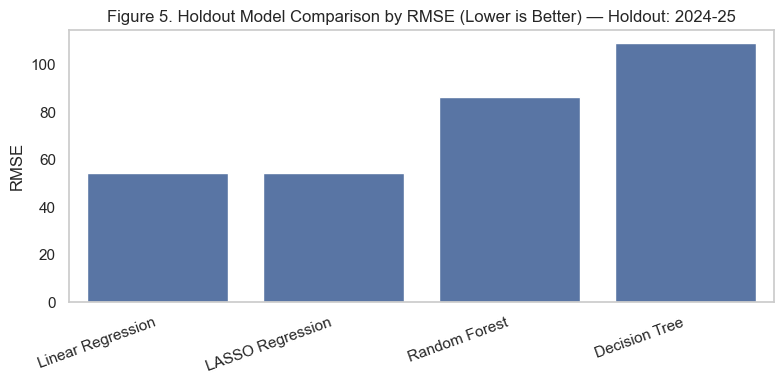

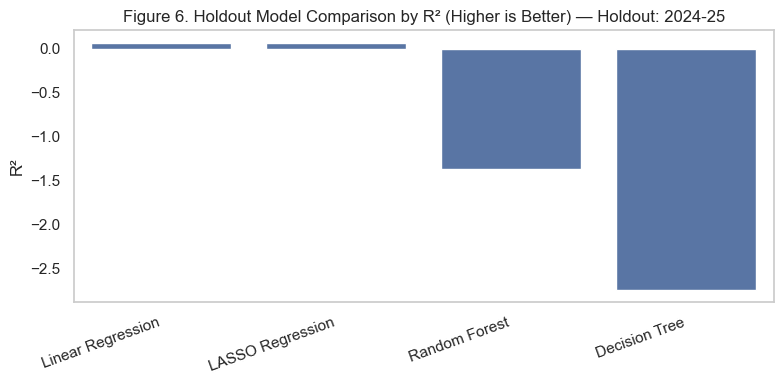

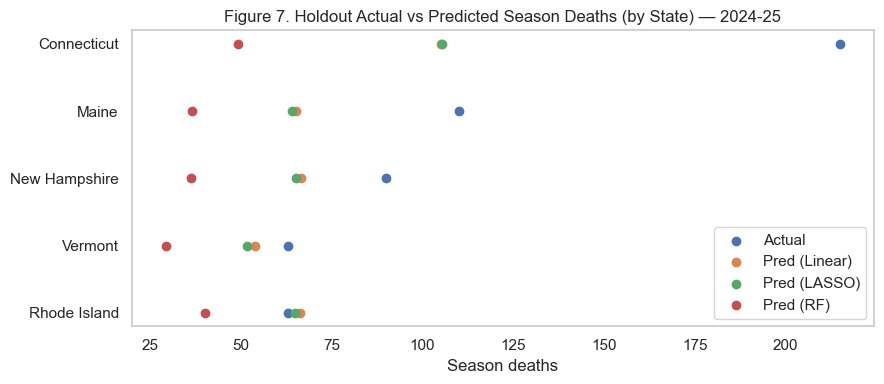


TABLE 12. Weekly Classification Model Metrics (High next-week deaths)
                          Model  Accuracy  Precision  Recall     F1
0  Logistic Regression (Weekly)     0.846      0.849   0.517  0.643


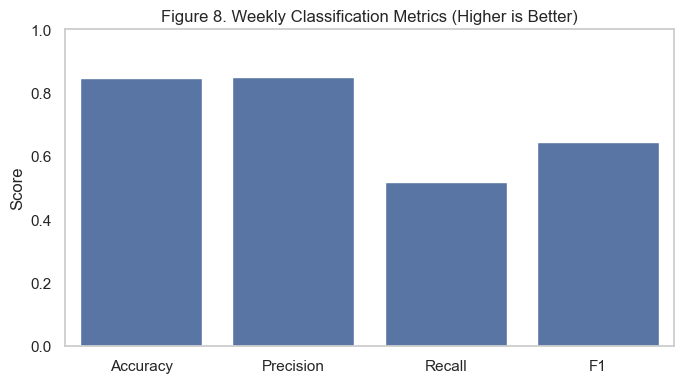

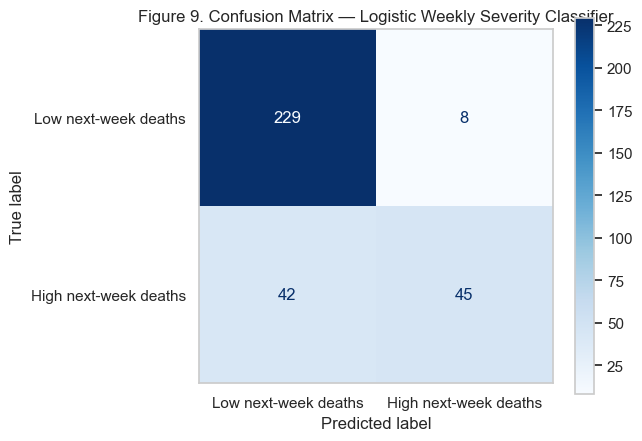


MODEL COMPARISON INTERPRETATION:
- For end-of-season prediction (holdout 2024-25), best RMSE model = Linear Regression.
- For weekly operational early-warning, Logistic classification is evaluated with Accuracy/Precision/Recall/F1 + confusion matrix.
- If your goal is 'forecast season burden', report regression results; if your goal is 'trigger surge readiness early', report classification results.


In [42]:
# =========================================================
# 9b. MODEL COMPARISON (report-friendly + graphs)
# Compare: Linear, LASSO, Tree, RF (holdout regression)
# + Logistic (weekly classification)
# =========================================================

# ---------- Regression models (holdout season) ----------
reg_results = pd.DataFrame([
    {"Model": "Linear Regression", "RMSE": rmse(y_test, pred_lr), "MAE": mean_absolute_error(y_test, pred_lr), "R2": r2_score(y_test, pred_lr)},
    {"Model": "LASSO Regression",  "RMSE": rmse(y_test, pred_lasso), "MAE": mean_absolute_error(y_test, pred_lasso), "R2": r2_score(y_test, pred_lasso)},
    {"Model": "Decision Tree",     "RMSE": rmse(y_test, pred_tree), "MAE": mean_absolute_error(y_test, pred_tree), "R2": r2_score(y_test, pred_tree)},
    {"Model": "Random Forest",     "RMSE": rmse(y_test, pred_rf), "MAE": mean_absolute_error(y_test, pred_rf), "R2": r2_score(y_test, pred_rf)},
])

reg_results = reg_results.sort_values(["RMSE", "R2"], ascending=[True, False]).reset_index(drop=True)

print("\nTABLE 11. Holdout Regression Model Comparison (End-of-season deaths)")
print(reg_results.round(2))

best_reg_model = reg_results.iloc[0]["Model"]
best_reg_rmse = reg_results.iloc[0]["RMSE"]
best_reg_r2 = reg_results.iloc[0]["R2"]

print(f"\nBest holdout regression model by RMSE: {best_reg_model} (RMSE={best_reg_rmse:.2f}, R²={best_reg_r2:.2f})")

# ---------- Plot 1: RMSE comparison ----------
plt.figure(figsize=(8,4))
sns.barplot(data=reg_results, x="Model", y="RMSE")
plt.title(f"Figure 5. Holdout Model Comparison by RMSE (Lower is Better) — Holdout: {holdout}")
plt.xlabel("")
plt.ylabel("RMSE")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.grid(False)
plt.show()

# ---------- Plot 2: R² comparison ----------
plt.figure(figsize=(8,4))
sns.barplot(data=reg_results, x="Model", y="R2")
plt.title(f"Figure 6. Holdout Model Comparison by R² (Higher is Better) — Holdout: {holdout}")
plt.xlabel("")
plt.ylabel("R²")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.grid(False)
plt.show()

# ---------- Optional: Actual vs Predicted  ----------

holdout_plot = test_df[["state","season","season_deaths"]].copy()
holdout_plot["Pred_LR"] = pred_lr
holdout_plot["Pred_LASSO"] = pred_lasso
holdout_plot["Pred_RF"] = pred_rf

holdout_plot = holdout_plot.sort_values("season_deaths")

plt.figure(figsize=(9,4))
plt.scatter(holdout_plot["season_deaths"], holdout_plot["state"], label="Actual")
plt.scatter(holdout_plot["Pred_LR"], holdout_plot["state"], label="Pred (Linear)")
plt.scatter(holdout_plot["Pred_LASSO"], holdout_plot["state"], label="Pred (LASSO)")
plt.scatter(holdout_plot["Pred_RF"], holdout_plot["state"], label="Pred (RF)")
plt.title(f"Figure 7. Holdout Actual vs Predicted Season Deaths (by State) — {holdout}")
plt.xlabel("Season deaths")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.grid(False)
plt.show()

# ---------- Classification model (weekly) ----------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

acc = accuracy_score(yc_test, pred_cls)
prec = precision_score(yc_test, pred_cls, zero_division=0)
rec = recall_score(yc_test, pred_cls, zero_division=0)
f1 = f1_score(yc_test, pred_cls, zero_division=0)

cls_results = pd.DataFrame([{
    "Model": "Logistic Regression (Weekly)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1
}])

print("\nTABLE 12. Weekly Classification Model Metrics (High next-week deaths)")
print(cls_results.round(3))

# Plot: classification metric bars
cls_melt = cls_results.melt(id_vars="Model", value_vars=["Accuracy","Precision","Recall","F1"],
                            var_name="Metric", value_name="Score")

plt.figure(figsize=(7,4))
sns.barplot(data=cls_melt, x="Metric", y="Score")
plt.title("Figure 8. Weekly Classification Metrics (Higher is Better)")
plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Score")
plt.tight_layout()
plt.grid(False)
plt.show()

# Confusion matrix plot (required for logistic)
ConfusionMatrixDisplay.from_predictions(
    yc_test, pred_cls,
    display_labels=["Low next-week deaths", "High next-week deaths"],
    cmap="Blues"
)
plt.title("Figure 9. Confusion Matrix — Logistic Weekly Severity Classifier")
plt.tight_layout()
plt.grid(False)
plt.show()

# ---------- Simple interpretation printout ----------
print("\nMODEL COMPARISON INTERPRETATION:")
print(f"- For end-of-season prediction (holdout {holdout}), best RMSE model = {best_reg_model}.")
print("- For weekly operational early-warning, Logistic classification is evaluated with Accuracy/Precision/Recall/F1 + confusion matrix.")
print("- If your goal is 'forecast season burden', report regression results; if your goal is 'trigger surge readiness early', report classification results.")
